# Dependencies

In [14]:
!pip install pandas
!pip install numpy
!pip install matplotlib
!pip install torch
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 54.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.8/20.8 MB 59.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Iris Flower Dataset

In [28]:
df = pd.read_csv('IRIS.csv')
# df.head()
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [15]:
X = df.drop('species', axis=1)
y = df['species']

In [18]:
X_scaled = StandardScaler().fit_transform(X)

# PCA

In [21]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

In [24]:
df_3d = pd.DataFrame(data = X_pca_3d, columns = ['X1', 'X2', 'X3'])


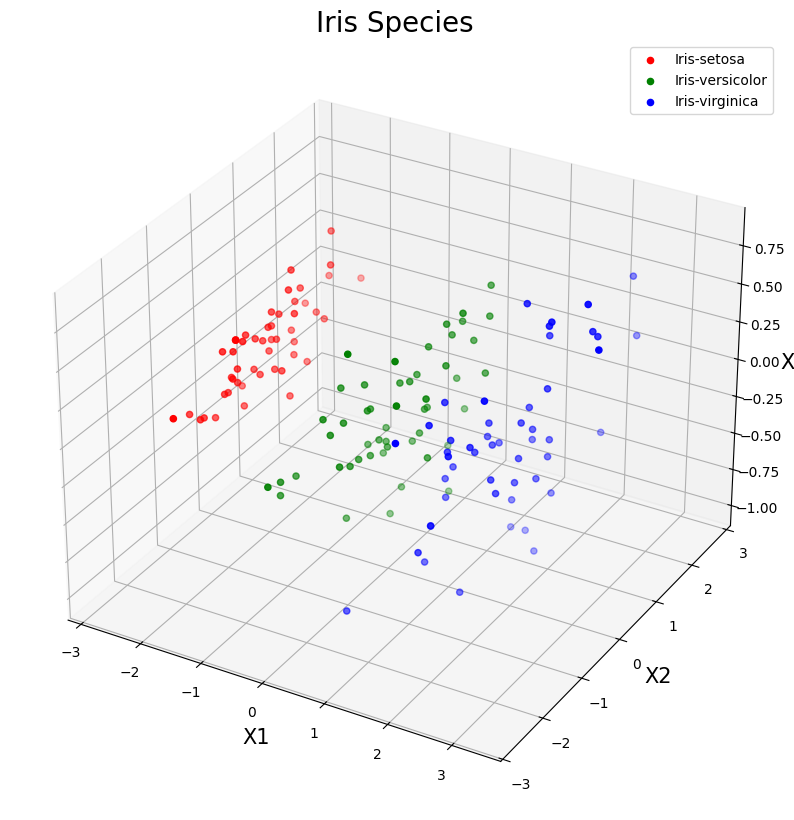

In [37]:
#  3D Plot
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X1', fontsize=15)
ax.set_ylabel('X2', fontsize=15)
ax.set_zlabel('X3', fontsize=15)
ax.set_title('Iris Species', fontsize=20)

targets = df['species'].unique().tolist()
colors = ['r', 'g', 'b']
for target, color in zip(targets, colors):
    indices_to_keep = y == target
    ax.scatter(df_3d.loc[indices_to_keep, 'X1'],
               df_3d.loc[indices_to_keep, 'X2'],
               df_3d.loc[indices_to_keep, 'X3'],
               c=color)
ax.legend(targets)
ax.grid()
plt.show()

# Classification 

In [40]:
# Encode the target variable
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [41]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

In [42]:
# Convert data to PyTorch Tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

In [56]:
class IrisNet(nn.Module):
    def __init__(self):
        super(IrisNet, self).__init__()
        self.fc1 = nn.Linear(4, 16) # 4 input features
        # self.fc2 = nn.Linear(16, 16)
        self.fc3 = nn.Linear(16, 3) # 3 output classes

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = IrisNet()
print(model)

IrisNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc3): Linear(in_features=16, out_features=3, bias=True)
)


In [57]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
epochs = 1000
losses = []
for epoch in range(epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 0.6323
Epoch [200/1000], Loss: 0.3962
Epoch [300/1000], Loss: 0.2699
Epoch [400/1000], Loss: 0.1852
Epoch [500/1000], Loss: 0.1348
Epoch [600/1000], Loss: 0.1068
Epoch [700/1000], Loss: 0.0892
Epoch [800/1000], Loss: 0.0778
Epoch [900/1000], Loss: 0.0702
Epoch [1000/1000], Loss: 0.0651


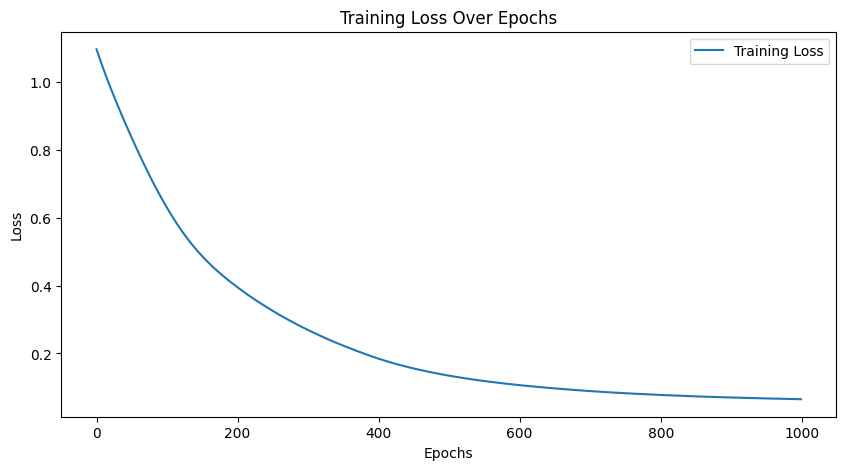

In [58]:
figure = plt.figure(figsize=(10, 5))
plt.plot(losses, label='Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.legend()
plt.show()

In [59]:
#  Test the model
with torch.no_grad():
    model.eval() # Set the model to evaluation mode
    outputs = model(X_test_tensor)
    _, predicted = torch.max(outputs.data, 1)
    
    total = y_test_tensor.size(0)
    correct = (predicted == y_test_tensor).sum().item()
    
    accuracy = 100 * correct / total
    print(f'Test Accuracy: {accuracy:.2f} %')

Test Accuracy: 100.00 %
